In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/AF_offline_inperson_sales_dataset.csv', on_bad_lines = 'skip')

In [3]:
pd.set_option('display.max_columns', None)

## Will Begin with the In-Store American Football Merchandise Sales Dataset

In [4]:
def data_organizer(df):
    df.drop_duplicates(inplace=True)

    # For this specific Dataset: I like Cleaner, Proper column names; so will Automate their Production
    if df.columns.str.contains('_').any():
        df.columns = [' '.join([word.capitalize() for word in col.split('_')]) for col in df.columns]
    numeric_cols = df.select_dtypes(include=['number']).columns  # Get numeric columns

    # Crucial: Checking for non-Numeric Characters in Numeric columns
    for col in numeric_cols:
        invalid_rows = df[df[col].astype(str).str.contains(r'[^0-9.-]', na=False)].index
        if len(invalid_rows) > 0:  # If Invalid rows are found, Removing them
            df.drop(index=invalid_rows, inplace=True)

    # I would like to see how many remaining Rows we have in the Dataset which contain any NULL value
    print(f"""The Dimensions of the Instances of the DataFrame containing any NULL value are: {df[df.isnull().any(axis=1)].shape}
          and the Columns that Contain any NULL Values are: {df.columns[df.isnull().any()].tolist()}""")

    print("")

    # Now, after this Preliminary "Organizing" (It was not Cleaned as much as was Processed for Future Cleaning), what are the Dataset's Details like?
    print(df.info())

# Also, notice I have only Intended to Firstly see the Amount of Rows we have containing NULLs, only
# I have not Removed them yet as I would first like to Review them and then see if I have to Remove or Replace the NULL values

In [ ]:
# df[df.isnull().any(axis = 1)] # If wanting to see all Rows that contain at least 1 NULL Value

In [5]:
data_organizer(df)

The Dimensions of the Instances of the DataFrame containing any NULL value are: (0, 20)
          and the Columns that Contain any NULL Values are: []

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501000 entries, 0 to 500999
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Product Name        501000 non-null  object 
 1   Brand               501000 non-null  object 
 2   Category            501000 non-null  object 
 3   Subcategory         501000 non-null  object 
 4   Supplier            501000 non-null  object 
 5   Date                501000 non-null  object 
 6   Price               501000 non-null  float64
 7   Quantity Sold       501000 non-null  int64  
 8   Amount Sold         501000 non-null  float64
 9   Cost Amount         501000 non-null  float64
 10  Payment Method      501000 non-null  object 
 11  Customer Firstname  501000 non-null  object 
 12  Customer Lastname   501000 non-n

In [6]:
df['Date'] = pd.to_datetime(df['Date']) # Converting the "Date" column to the Appropriate Data Type too

# Also, defining Functions to convert however many columns to the Desired Data Types, respectively

def str_maker(df, *cols):
  for i in cols:
    df[i] = df[i].astype(str)

def num_maker(df, *cols):
  for i in cols:
    df[i] = pd.to_numeric(df[i])

In [7]:
str_maker(df, "Customer Phone")

# df.dtypes # There we go!

In [ ]:
df.head(7)

,Product Name,Brand,Category,Subcategory,Supplier,Date,Price,Quantity Sold,Amount Sold,Cost Amount,Payment Method,Customer Firstname,Customer Lastname,Customer Gender,Customer Email,Customer Phone,Store Type,Store Street,Store City,Store State
0,Riddell Victor-I Inflation Air Bladder (R91229...,Riddell,Helmets,Helmet Components,Balistreri Inc.,2023-07-31 16:54:01,16.11,4,64.44,29.76,cash,Farleigh,Geach,Male,fgeach55@aol.com,296-345-9732,specialized,20 Fairfield Plaza,Portland,OR
1,McDavid Thigh Support,McDavid,Protective Gear,Thigh,NFL Properties LLC,2023-03-16 20:06:34,20.00,6,120.00,81.36,debit card,Stesha,Peiser,Female,speiserl@squarespace.com,562-102-4205,superstore,654 Pine View Place,New Orleans,LA
2,SportStar SpeedFlex Adapter/Set,SportStar,Helmets,Helmet Components,Forelle Inc.,2023-04-01 08:44:54,55.18,9,496.62,122.31,cash,Luciana,Colleford,Female,lcollefordm@zdnet.com,726-840-1316,superstore,7 Transport Court,Clearwater,FL
3,Riddell G3BD (R74975),Riddell,Helmets,Face Masks,Franklin Sports,2022-04-13 01:48:43,39.34,1,39.34,20.05,bank transfer,Percy,Folbigg,Male,pfolbigg9u@live.com,437-794-0956,superstore,6451 Gina Center,Amarillo,TX
4,Riddell SF-2EG-TX (R954SP6),Riddell,Helmets,Face Masks,Certor Sports LLC,2023-02-09 08:33:54,53.46,1,53.46,18.47,cash,Dorian,Blackborne,Female,dblackborne1m@tmall.com,992-989-8895,superstore,247 Mariners Cove Alley,Irving,TX
5,Neumann Lineman Open Fingers (FBL41),Neumann,Gloves,Adult,Krausko LLC,2022-11-21 17:35:08,166.46,1,166.46,45.86,credit card,Oralla,Halewood,Female,ohalewoodi7@themeforest.net,650-161-6355,superstore,14615 Twin Pines Pass,Vero Beach,FL
6,Riddell Kombine LN,Riddell,Shoulder Pads,Adult,Nerion Athletics Group,2023-10-19 17:05:51,155.92,7,1091.44,738.36,credit card,Beverlee,Spratley,Female,bspratleynr@stumbleupon.com,176-769-0072,superstore,05227 Grasskamp Park,Lansing,MI


#### Outlier/Anomaly Detection

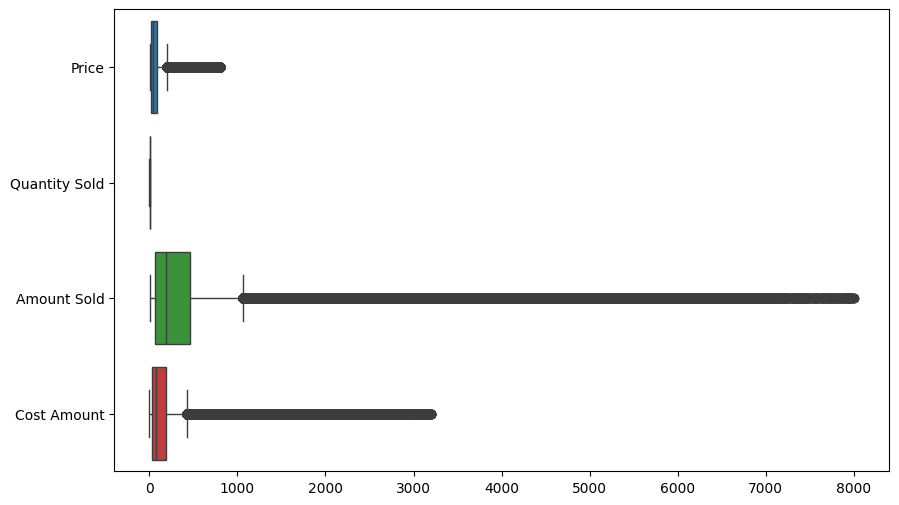

In [ ]:
# Current (Original) Boxplot of the Numerical variables

plt.figure(figsize = (10, 6))
sns.boxplot(data = df, orient = 'h')
plt.show()

In [8]:
# Defining a Function to Remove Outliers based on the IQR Method

def remove_outliers_iqr(df, columns=None, multiplier=1.5): # "Q1 - 1.5*IQR" or "Q3 + 1.5*IQR"
    """
    Removes outliers based on Interquartile Range (IQR) method for selected Numeric columns.

    Parameters:
    df (pd.DataFrame): Your DataFrame
    columns (list): List of numeric column names to apply filtering on; if None, applies to all numeric columns.
    multiplier (float): IQR multiplier (default is 1.5)

    Returns:
    pd.DataFrame: Filtered DataFrame
    """
    df_clean = df.copy()
    if columns is None:
        columns = df_clean.select_dtypes(include='number').columns

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        outlier_count = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].shape[0]
        print(f"Column '{col}': Removed {outlier_count} outliers")

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        df = df_clean.copy()

    return df

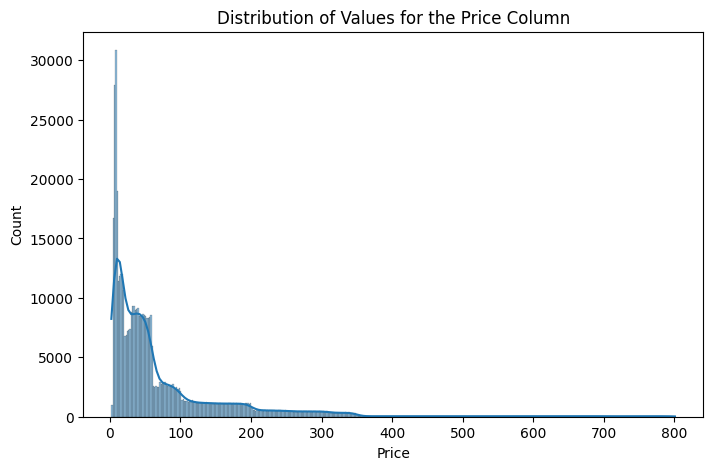

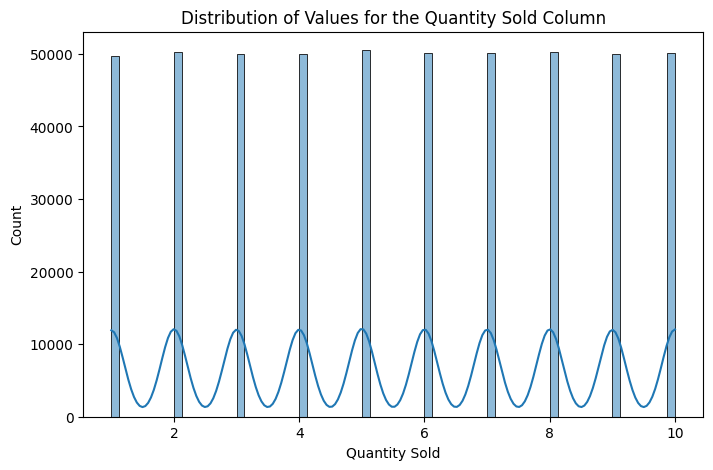

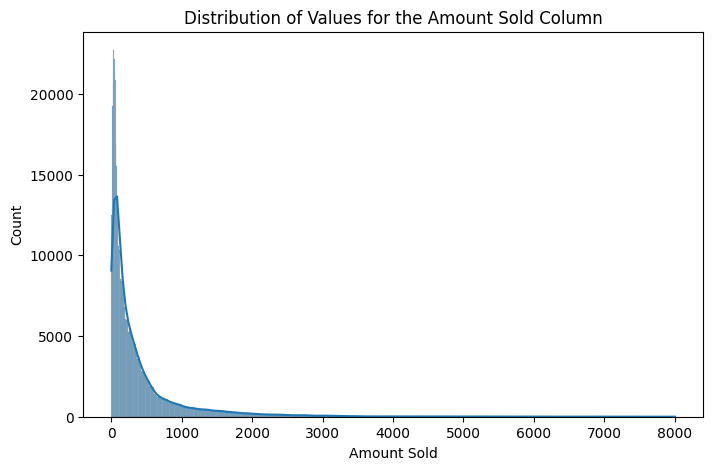

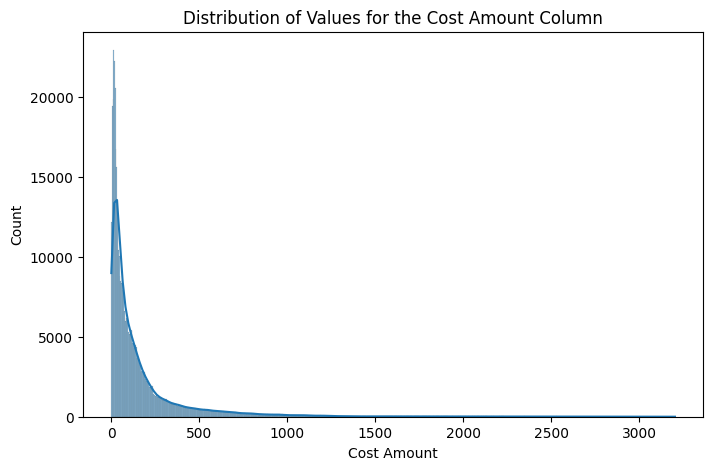

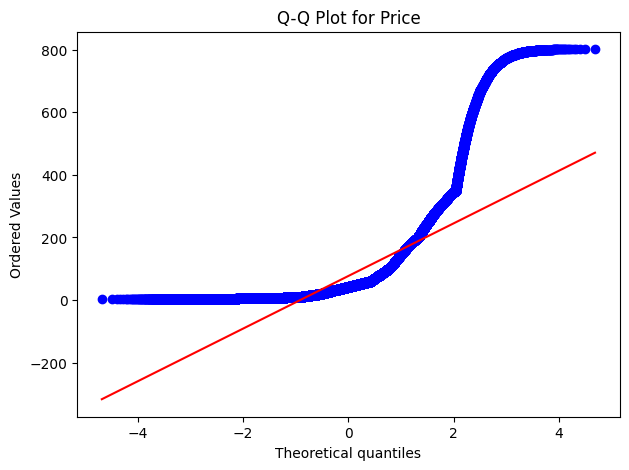

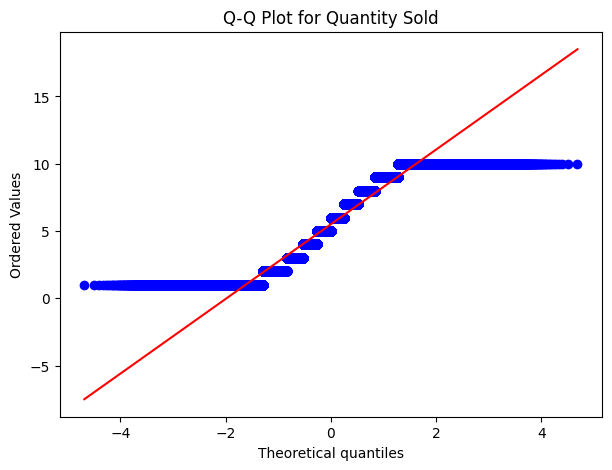

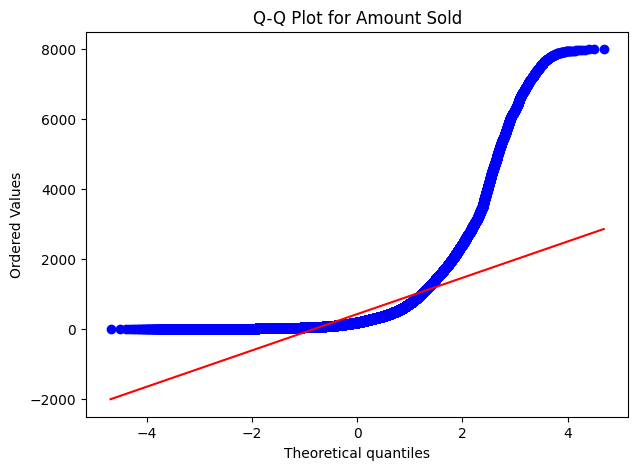

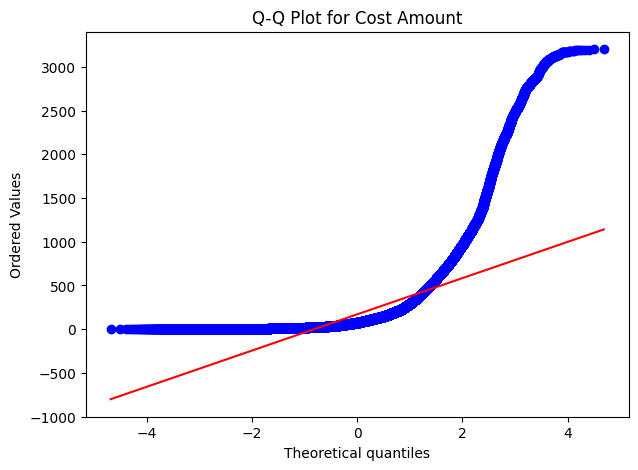

In [ ]:
# Before we proceed to Outlier Removal, let's also Explore if the Numeric columns are Skewed or Normally Distributed

for col in df.select_dtypes(include = 'number').columns:
  plt.figure(figsize = (8, 5))
  sns.histplot(data = df[col], kde = True)
  plt.title(f"Distribution of Values for the {col} Column")
  plt.xlabel(f"{col}")
  plt.show()

# OPTIONAL and Better to Include & Test on: Q-Q Plot

import scipy.stats as stats

for col in df.select_dtypes(include = 'number').columns:
  plt.figure(figsize = (7, 5))
  stats.probplot(df[col], dist="norm", plot = plt)
  plt.title(f"Q-Q Plot for {col}")
  plt.show() # None of the Plots have points falling on the Straigth, Diagonal line; hence, confirmed that None is Normally Distributed

NOTES: **Statistical Test to confirm Confidence**

from scipy.stats import shapiro # Shapiro-Wilk Test

stat, p = shapiro(df['col'])
print(f'Shapiro-Wilk p-value: {p}') # p-value > 0.05; Data = ~Normally Distributed (Use Z-Score-based Removal ONLY WHEN Visuals + p-value > 0.05 both support it)

If Data appears "Skewed" and p-value > 0.05; for sure use it, and even if it appears "Skewed" and p-value < 0.05; still can go ahead with IQR Removal as it is more Distribution-Agnostic

In [9]:
# I think it's safe to go with IQR-based Anomaly Removal for all Numeric columns except 'Quantity Sold'

df[['Price', 'Amount Sold', 'Cost Amount']] = remove_outliers_iqr(df[['Price', 'Amount Sold', 'Cost Amount']])

Column 'Price': Removed 47590 outliers
Column 'Amount Sold': Removed 32948 outliers
Column 'Cost Amount': Removed 26095 outliers


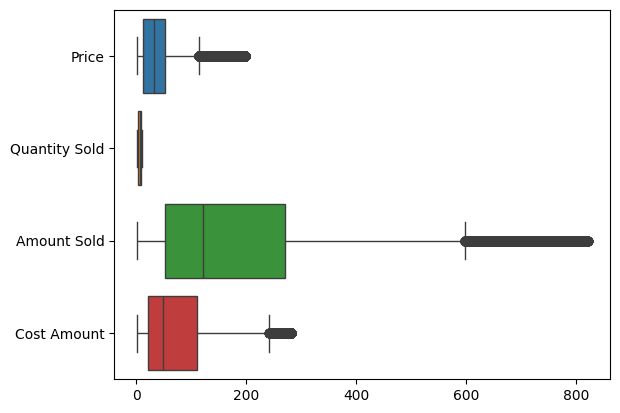

In [ ]:
# Boxplot of Numeric columns after Outlier Removal

sns.boxplot(data = df, orient = 'h')
plt.show() # They all look Better now!

In [10]:
# Let's also Replace the NULL values

numeric_cols = df.select_dtypes(include='number')
df[numeric_cols.columns] = numeric_cols.fillna(numeric_cols.mean().round(2))

# There we go
df.isnull().sum()

,0
Product Name,0
Brand,0
Category,0
Subcategory,0
Supplier,0
Date,0
Price,0
Quantity Sold,0
Amount Sold,0
Cost Amount,0


## EDA: Descriptive Statistics and Data Analysis & Visualization

In [ ]:
df.select_dtypes(include = 'number').describe().round(2)

,Price,Quantity Sold,Amount Sold,Cost Amount
count,501000.00,501000.00,501000.00,501000.00
mean,39.63,5.50,182.63,72.48
std,32.19,2.87,149.80,57.59
min,1.99,1.00,2.05,0.80
25%,15.85,3.00,66.32,26.56
50%,39.63,6.00,182.63,72.48
75%,46.78,8.00,219.16,89.04
max,198.32,10.00,821.55,282.40


In [ ]:
pd.pivot_table(df, index = 'Category', values = ['Quantity Sold', 'Amount Sold'], aggfunc = 'sum').sort_values(by = 'Amount Sold', ascending = False)

,Amount Sold,Quantity Sold
Category,,
Helmets,34524311.35,1076805
Shoulder Pads,14224667.03,384884
Gloves,12522480.90,258216
Protection,10287888.68,447707
Clothing & Apparel,9377386.84,190612
Footwear,5789077.38,206128
Protective Gear,2996600.37,72494
Accessories,1776689.48,120089


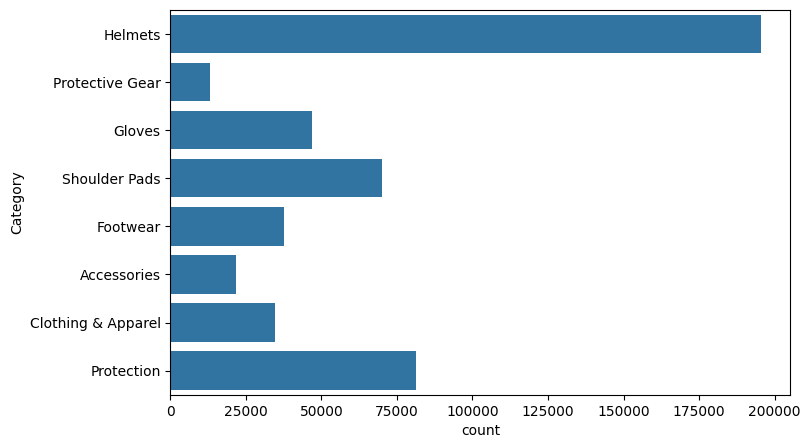

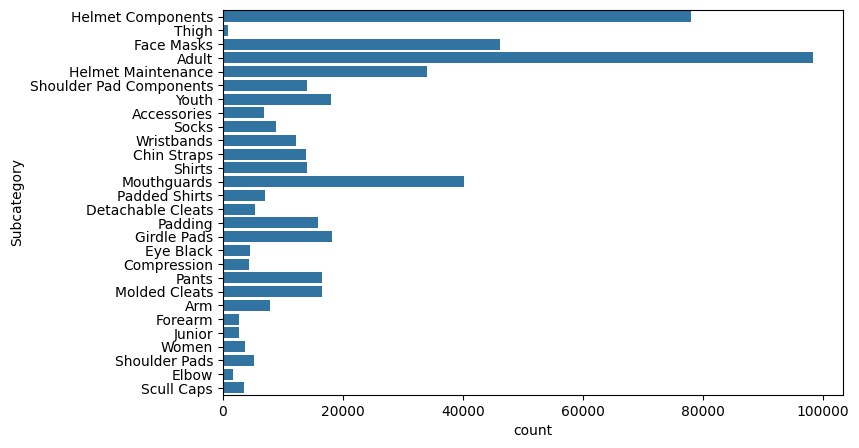

In [ ]:
counts = ['Category', 'Subcategory']

for i in counts:
  plt.figure(figsize = (8, 5))
  sns.countplot(df[i])
  plt.ylabel(f"{df[i].name}")
  plt.show()

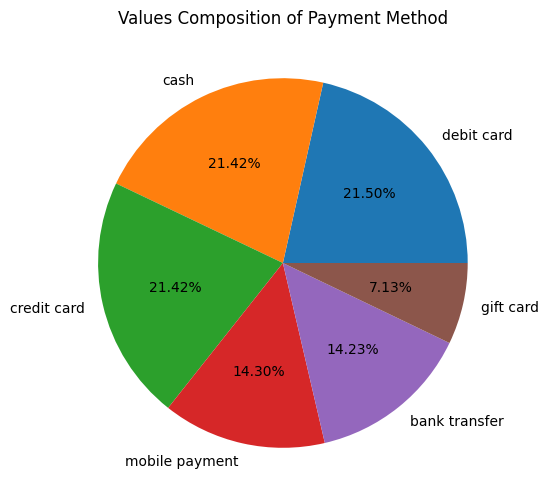

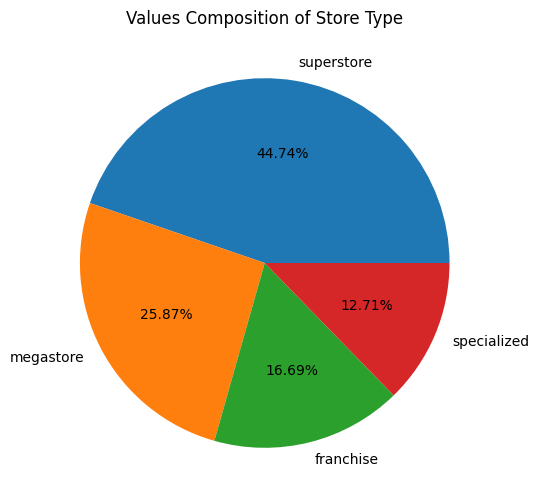

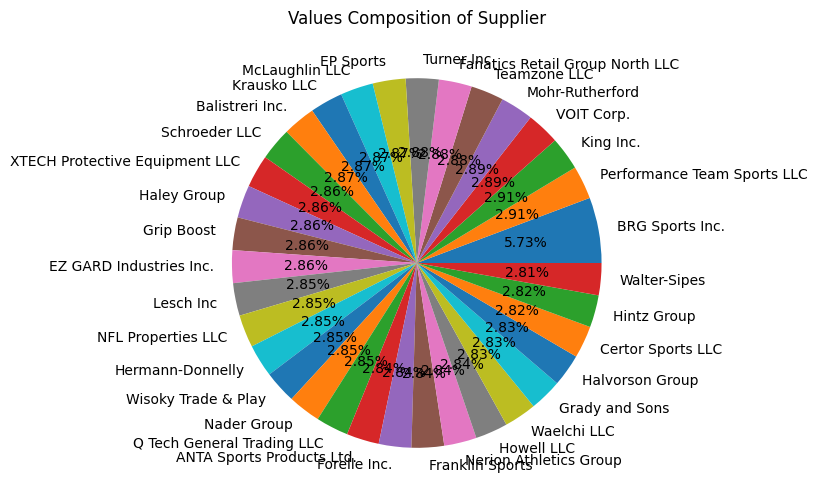

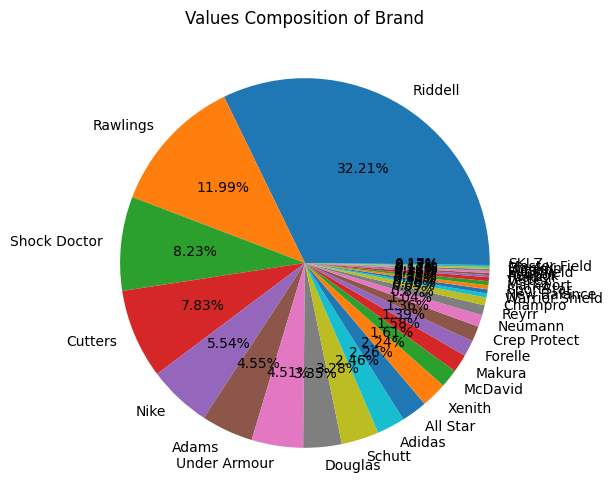

In [ ]:
cate_cols = ['Payment Method', 'Store Type',
             'Supplier', 'Brand']

for i in cate_cols:
  plt.figure(figsize = (8, 6))
  plt.pie(df[i].value_counts(normalize = True), labels = df[i].value_counts().index, autopct = '%1.2f%%')
  plt.title(f"Values Composition of {df[i].name}")
  plt.show()

# There were too many Values for "Customer State"; so, I will Create a Separate Bar Graph for that Column

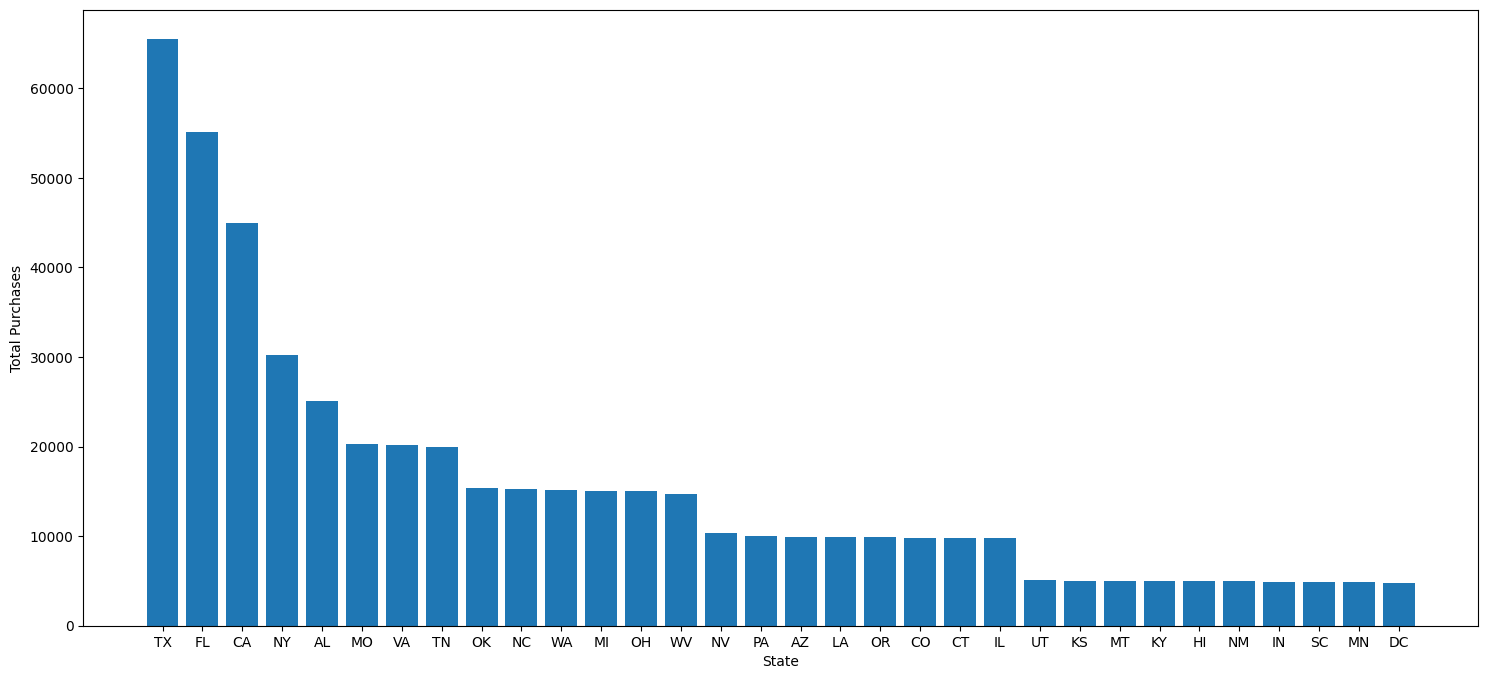

In [ ]:
# I do not want to Exclude any State; I am going to look at all Values & Inspect, at least for now

plt.figure(figsize = (18, 8))
plt.bar(df['Store State'].value_counts().index, df['Store State'].value_counts())
plt.xlabel('State')
plt.ylabel('Total Purchases')
plt.show() # TX tops the list for all in-store business, followed closely California and then Florida and New York

More Focused and Detailed Boxplots:

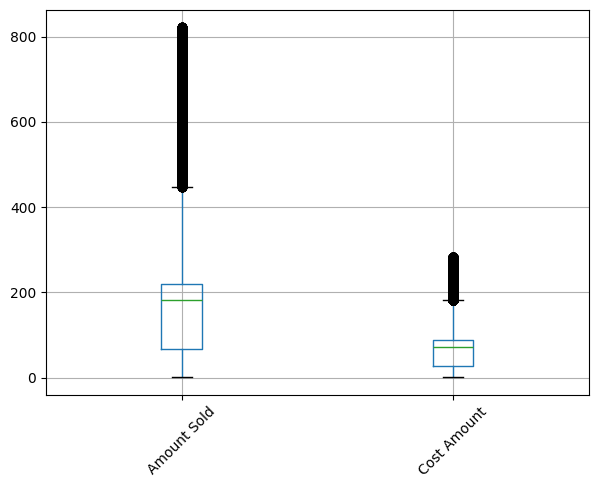

In [ ]:
# "Total Amount" and "Total Costs" Columns have Ranges of Values way higher than other Numerical Columns; thus, we will Visualize them Separately

plt.figure(figsize = (7, 5))
df[['Amount Sold', 'Cost Amount']].boxplot()
plt.xticks(rotation = 45)
plt.show()

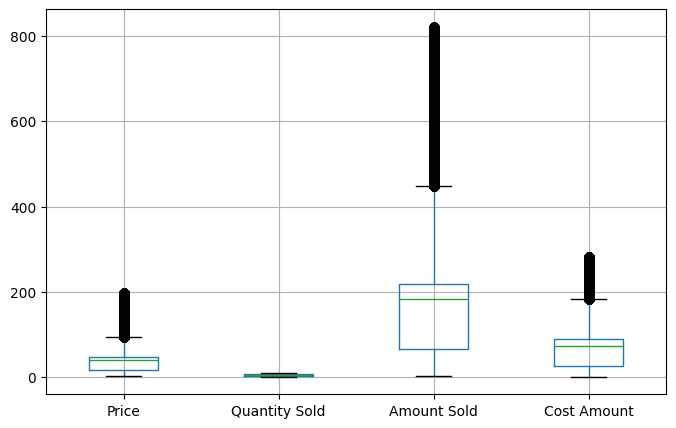

In [ ]:
# Boxplot of all Numerical variables
plt.figure(figsize = (8, 5))
df.boxplot()
plt.show()

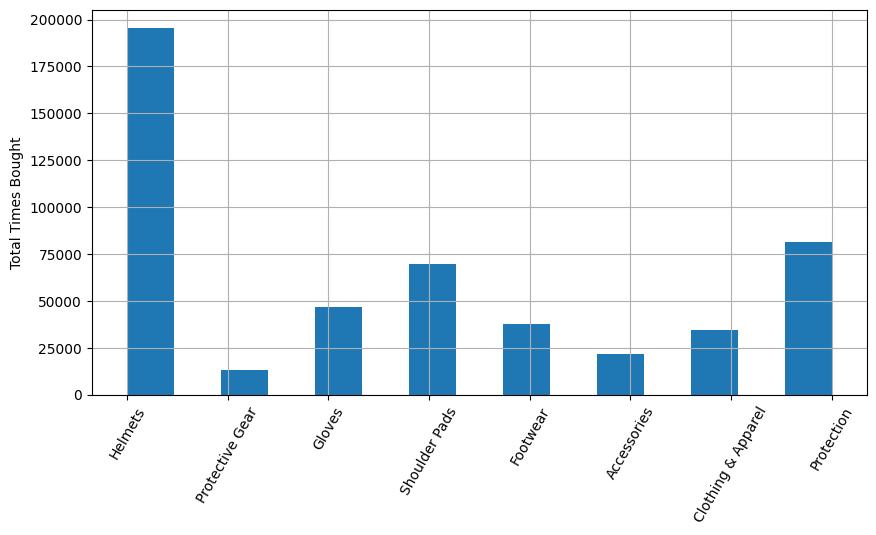

In [ ]:
# Histogram Depicting Total Count of Purchases of each Item Category

plt.figure(figsize = (10, 5))
df['Category'].hist(bins = 15)
plt.xticks(rotation = 60)
plt.ylabel("Total Times Bought")
plt.show()

In [ ]:
pd.pivot_table(df, index = ['Brand', 'Product Name'], values = 'Price', aggfunc = 'mean').round(2).sort_values(by = 'Price', ascending = False)

Price
Brand    Product Name                                   
Rawlings Rawlings F4535 Adult                      79.07
Adidas   Adidas Audible Padded Adult Pants (609P)  78.67
Rawlings Rawlings YFP147 Youth                     78.60
         Rawlings YF25P Youth D-Flexion            77.72
Riddell  Riddell Safety Pants w/Pads Adult         77.58
...                                                  ...
Franklin Eye Black Stickers                         6.52
Rawlings Eye Black Stickers                         6.45
         Wide-Body Eye Black                        6.45
         Eye Stickers Coloured                      6.41
         Eye Stickers                               6.37

[574 rows x 1 columns]

In [ ]:
df.groupby('Brand')['Price'].mean().round(2).sort_values(ascending = False).head(12)

# The "Rawlings" Brand has the Overall Cheapest products, but also boasts 2 of the most Expensive ones^

,Price
Brand,
SKLZ,74.01
Neumann,72.69
New Balance,65.49
Reebok,63.83
Cutters,60.30
Riddell,57.52
Warrior Shield,52.91
Schutt,51.91
Xenith,51.52


### Converting the "tmstmp" Column into new Columns for better Time-based Plot(s) & Analysis(es)

In [11]:
# Extract Year, Month, Day, and Time components
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Time'] = df['Date'].dt.strftime('%I:%M %p')

# Display the updated DataFrame (optional)
print(df[['Year', 'Month', 'Day', 'Time']].head())

   Year  Month  Day      Time
0  2023      7   31  04:54 PM
1  2023      3   16  08:06 PM
2  2023      4    1  08:44 AM
3  2022      4   13  01:48 AM
4  2023      2    9  08:33 AM


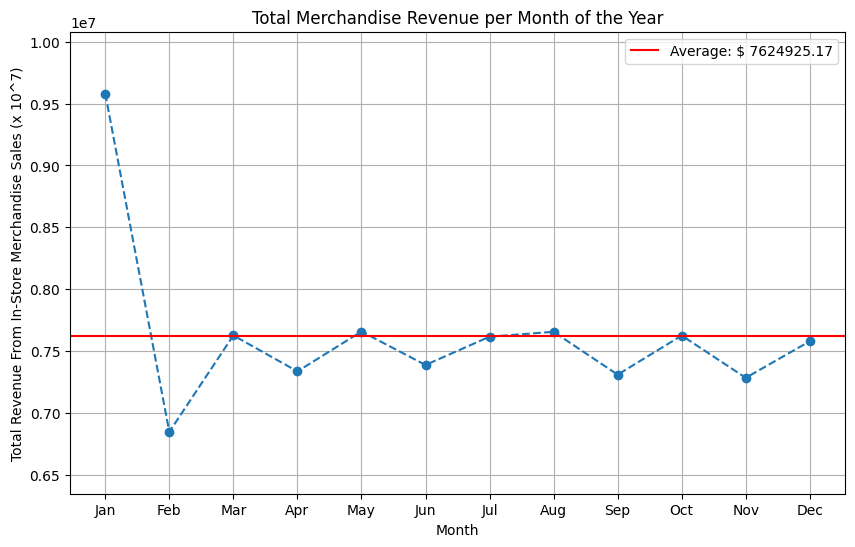

In [ ]:
# I was planning to Create a Line graph for Yearly sales, but the Range for that is too Small (2022-2024)

salespm = df.groupby('Month')['Amount Sold'].sum()
# salespm_avg = df.groupby('Month')['Amount Sold'].mean().round(2)

plt.figure(figsize = (10, 6))
plt.plot(salespm.index, salespm.values, linewidth = 1.5, linestyle = '--', marker = 'o')
plt.xlabel("Month")
plt.ylabel("Total Revenue From In-Store Merchandise Sales (x 10^7)")
plt.ylim(salespm.min() - 500000, salespm.max() + 500000)
plt.axhline(y = salespm.mean(), color = 'red', linestyle = '-', label = f"Average: ${salespm.mean(): .2f}")
plt.xticks(salespm.index, ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]) #, rotation = 60)

plt.grid(True)
plt.legend()
plt.title("Total Merchandise Revenue per Month of the Year")
plt.show()

# Wow! Sooo much Revenue - the Highest - is earned in January! That does not even extend to February; probably because the Final Playoffs are held in January and the Super Bowl is completed in February, after which Sales might decrease due to the Offseason starting

## Feature Engineering (Not all Performed tasks might be used in ML)

The NULL values in columns have already been Dropped or Replaced (sort of "Imputed") with Mean values, as needed, earlier in the project.

1. Creating a new Column: Ratio of Revenue Generated to Cost Incurred per Sale.

(This was done in PostgreSQL too, for some analyses - might be useful.)

In [12]:
df['Revenue-to-Cost Ratio'] = (df['Amount Sold']/df['Cost Amount']).round(2).astype(float)

2. Label Encoding the "Payment Method" column.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder() # Could've used a Simple OneHot Encoder or "get_dummies()" but I wanted separate Numbering for each Categorical value

# I really want to see if the type of Payment Method you have affects how much you Buy (Measured in "Amount Sold" for the Seller, which will be the Target variable in our Multiple Regression model)

paytype = encoder.fit_transform(df[['Payment Method']])

df_paytype = pd.DataFrame(paytype, columns = ['Payment Method Encoded'])

df = pd.concat([df, df_paytype], axis = 1)

# df.drop(['Payment Method'], axis = 1, inplace = True)

*   **0:** Bank Transfer
*   **1:** Cash
*   **2:** Credit Card
*   **3:** Debit Card
*   **4:** Gift Card
*   **5:** Mobile Payment

3. Binning Product Prices into Categories.

In [16]:
price_bins = [df["Price"].min()-1, df["Price"].quantile(0.25), df["Price"].quantile(0.50), df["Price"].quantile(0.75), df["Price"].max()+1]
price_types = ["Cheap", "Average", "Above Average", "Expensive"]

df["Price Category"] = pd.cut(df["Price"], bins = price_bins, labels = price_types) # Will see if I want to use them in any Model or not, even after One-Hot/Label Encoding them

# Let's Save the New, Modified DataFrame for all In-Person Sales
df.to_csv('inperson_sales.csv', index = False)

df.head(6)

,Product Name,Brand,Category,Subcategory,Supplier,Date,Price,Quantity Sold,Amount Sold,Cost Amount,Payment Method,Customer Firstname,Customer Lastname,Customer Gender,Customer Email,Customer Phone,Store Type,Store Street,Store City,Store State,Year,Month,Day,Time,Revenue-to-Cost Ratio,Price Category
0,Riddell Victor-I Inflation Air Bladder (R91229...,Riddell,Helmets,Helmet Components,Balistreri Inc.,2023-07-31 16:54:01,16.11,4,64.44,29.76,cash,Farleigh,Geach,Male,fgeach55@aol.com,296-345-9732,specialized,20 Fairfield Plaza,Portland,OR,2023,7,31,04:54 PM,2.17,Average
1,McDavid Thigh Support,McDavid,Protective Gear,Thigh,NFL Properties LLC,2023-03-16 20:06:34,20.00,6,120.00,81.36,debit card,Stesha,Peiser,Female,speiserl@squarespace.com,562-102-4205,superstore,654 Pine View Place,New Orleans,LA,2023,3,16,08:06 PM,1.47,Average
2,SportStar SpeedFlex Adapter/Set,SportStar,Helmets,Helmet Components,Forelle Inc.,2023-04-01 08:44:54,55.18,9,496.62,122.31,cash,Luciana,Colleford,Female,lcollefordm@zdnet.com,726-840-1316,superstore,7 Transport Court,Clearwater,FL,2023,4,1,08:44 AM,4.06,Expensive
3,Riddell G3BD (R74975),Riddell,Helmets,Face Masks,Franklin Sports,2022-04-13 01:48:43,39.34,1,39.34,20.05,bank transfer,Percy,Folbigg,Male,pfolbigg9u@live.com,437-794-0956,superstore,6451 Gina Center,Amarillo,TX,2022,4,13,01:48 AM,1.96,Average
4,Riddell SF-2EG-TX (R954SP6),Riddell,Helmets,Face Masks,Certor Sports LLC,2023-02-09 08:33:54,53.46,1,53.46,18.47,cash,Dorian,Blackborne,Female,dblackborne1m@tmall.com,992-989-8895,superstore,247 Mariners Cove Alley,Irving,TX,2023,2,9,08:33 AM,2.89,Expensive
5,Neumann Lineman Open Fingers (FBL41),Neumann,Gloves,Adult,Krausko LLC,2022-11-21 17:35:08,166.46,1,166.46,45.86,credit card,Oralla,Halewood,Female,ohalewoodi7@themeforest.net,650-161-6355,superstore,14615 Twin Pines Pass,Vero Beach,FL,2022,11,21,05:35 PM,3.63,Expensive


3. One-Hot Encoding the **Month** column.

In [ ]:
# May have a Regression Model for this only, Separate
encoded_df = pd.get_dummies(df[['Payment Method', 'Month']])

encoded_df.head(6)

,Month,Payment Method_bank transfer,Payment Method_cash,Payment Method_credit card,Payment Method_debit card,Payment Method_gift card,Payment Method_mobile payment
0,7,False,True,False,False,False,False
1,3,False,False,False,True,False,False
2,4,False,True,False,False,False,False
3,4,True,False,False,False,False,False
4,2,False,True,False,False,False,False
5,11,False,False,True,False,False,False


(4. Min-Max Scaling: But this will be done within the Machine Learning section)

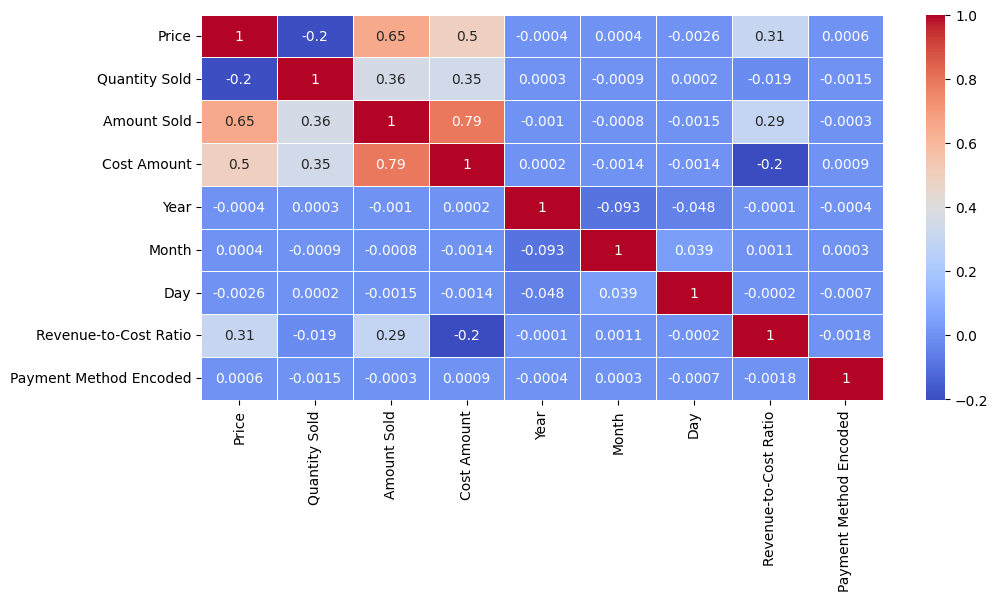

In [ ]:
corrs = df.corr(numeric_only = True).round(4)

plt.figure(figsize = (11, 5))
sns.heatmap(corrs, annot = True, cmap = 'coolwarm',
            linewidth = 0.7)
plt.show()

# Best Predictor Variables for predicting "Amount Sold" appear to be:
## "Price", "Quantity Sold", "Cost Amount", and "Revenue-to-Cost Ratio"

## Machine Learning

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler
# import statsmodels.api as sm

# Defining the X and the y
X = df[["Price", "Quantity Sold", "Cost Amount", "Revenue-to-Cost Ratio"]]
y = df["Amount Sold"] # Target Variable: Total Revenue Generated from Sale

# Splitting the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Target variable too
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1))

# Linear Regression model
lr = LinearRegression()
lr_model = lr.fit(X_train_scaled, y_train_scaled)
y_pred_lr_scaled = lr.predict(X_test_scaled)
y_pred_lr = scaler.inverse_transform(y_pred_lr_scaled)

# Evaluate the model
mse = round(mean_squared_error(y_test, y_pred_lr), 2)
rmse = round(root_mean_squared_error(y_test, y_pred_lr), 2)
r2 = round(r2_score(y_test, y_pred_lr)*100, 2)

print("Mean Squared Error:", mse)
## RMSE is in the Same Units as the Target variable
print("Root Mean Squared Error:", rmse) # = 55.42; values of "Amount Sold" are generally 50-200. So, for higher values, this is reasonably good but for lower values, No
print("R-squared:", r2)
print("")
print(f"The Intercept for this Linear Regression Model is:", lr.intercept_) # When all Features are at their Scaled Minimum values (Zero), the Model predicts a Slightly Negative(-0.16) Revenue Generated
print("")
pd.DataFrame(lr.coef_.reshape(4, 1), index = X.columns, columns = ['Coefficient'])

# The Coefficient for "Payment Method Encoded" was too Small (0.000199); so, I'm removing it from the Model

Mean Squared Error: 3071.5
Root Mean Squared Error: 55.42
R-squared: 86.34

The Intercept for this Linear Regression Model is: [-0.16927948]



,Coefficient
Price,0.264287
Quantity Sold,0.100586
Cost Amount,0.611912
Revenue-to-Cost Ratio,0.998203


We can Separate Small and Large sales and/or Prices for different Models.

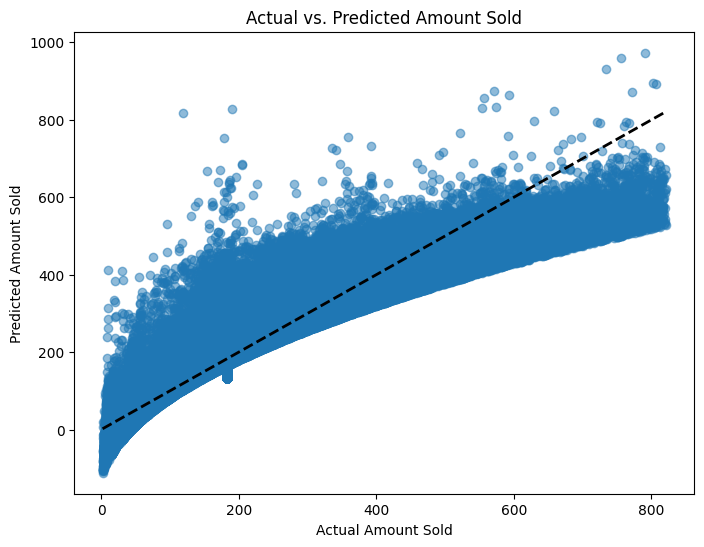

In [ ]:
# Actual vs. Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)  # Scatter plot of Actual VS Predicted
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel('Actual Amount Sold')
plt.ylabel('Predicted Amount Sold')
plt.title('Actual vs. Predicted Amount Sold')
plt.show() # Compares Actual values with Predicted values from the Multiple Linear Regression model^

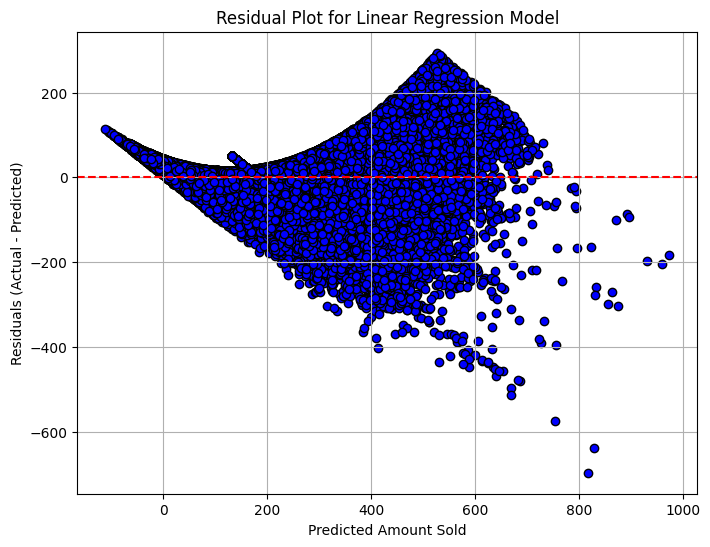

In [ ]:
# Residual Plot

# Calculate Residuals
residuals = y_test - y_pred_lr.flatten()

# Plot
plt.figure(figsize=(8,6))
plt.scatter(y_pred_lr, residuals, color="blue", edgecolor="k")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Amount Sold")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Linear Regression Model")
plt.grid(True)
plt.show()

# It Curves Downwards; Residuals are NOT Randomly Scattered around the Zero-line
# We were wrong to Assume Linearity; let's go for Polynomial Features or other Models

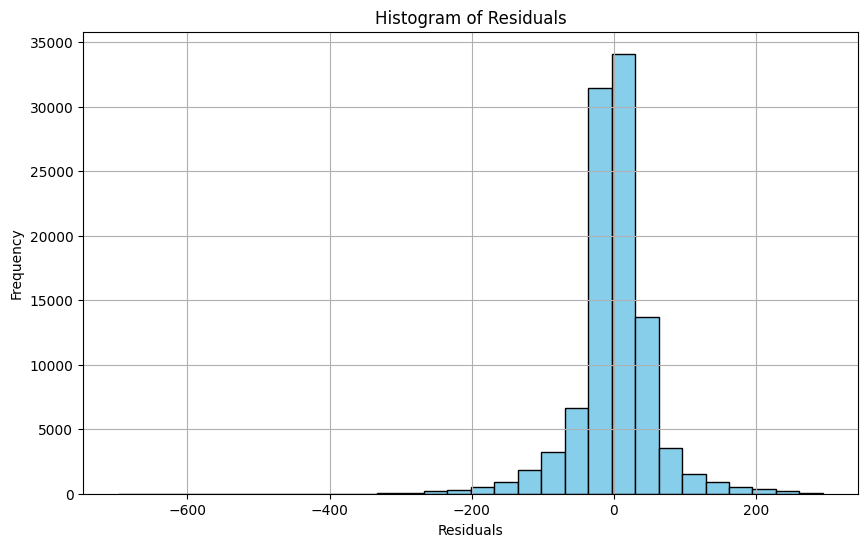

In [ ]:
# Histogram of Residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor="black", color="skyblue")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.grid(True)
plt.show() # Should look ~Bell-Shaped (Normally Distributed)

# Actually looks Normally Distributed

### Purely Linear Regression does not Evaluate well; the Features might be related to the Target variable in a Polynomial way.

#### Thus, we will Approach the problem in that way, then.

In [ ]:
# With Polynomial Features now

from sklearn.preprocessing import PolynomialFeatures

# 1. Define X and y
X = df[["Price", "Quantity Sold", "Cost Amount", "Revenue-to-Cost Ratio"]]
y = df["Amount Sold"]

# 2. Create Polynomial Features for Price and Cost Amount
poly = PolynomialFeatures(degree = 2, include_bias=False)
X_poly = poly.fit_transform(X[["Price", "Cost Amount"]])

# 3. Concatenate Polynomial Features with other Features
X_remaining = X.drop(["Price", "Cost Amount"], axis=1).values
X_final = np.hstack((X_remaining, X_poly))

# 4. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# 5. Scale the Data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1))

# 6. Train Linear Regression
lr = LinearRegression()
lr_model = lr.fit(X_train_scaled, y_train_scaled)
y_pred_scaled = lr.predict(X_test_scaled)
y_pred = scaler.inverse_transform(y_pred_scaled)

# 7. Evaluate
mse = round(mean_squared_error(y_test, y_pred), 2)
rmse = round(root_mean_squared_error(y_test, y_pred), 2)
r2 = round(r2_score(y_test, y_pred)*100, 2)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

print(f"The Intercept for this Linear Regression Model is:", lr.intercept_) # When all Features are at their Scaled Minimum values (Zero), the Model predicts a Slightly Negative(-0.16) Revenue Generated
print("")
print(lr.coef_)

## Get feature names after polynomial transformation
feature_names = poly.get_feature_names_out(input_features=["Price", "Cost Amount"])

## Combine original and polynomial feature names
all_feature_names = list(X.drop(["Price", "Cost Amount"], axis=1).columns) + list(feature_names)

pd.DataFrame(lr.coef_.reshape(len(all_feature_names), 1), index=all_feature_names,
             columns = ['Coefficient'])

Mean Squared Error: 2313.29
Root Mean Squared Error: 48.1
R-squared: 89.71
The Intercept for this Linear Regression Model is: [-0.18724582]

[[ 0.07551981  1.12015287  0.14974413  0.82271266 -0.36491892  0.99676105
  -0.5692697 ]]


,Coefficient
Quantity Sold,0.075520
Revenue-to-Cost Ratio,1.120153
Price,0.149744
Cost Amount,0.822713
Price^2,-0.364919
Price Cost Amount,0.996761
Cost Amount^2,-0.569270


### The Polynomial Regression model does look better. Still not Perfect, but Better for Predictive modeling, etc.

**Conclusions from the Regression model:**
*   The **Revenue-to-Cost Ratio (RTC)** of an Item is the strongest factor behind the Total Revenue earned in a Sale.
*   **Price Cost Amount** (the Transformation of "Price" and "Cost Amount" into a Single, Combined, Non-Linear variable of the Product's Sellng Price and Cost of Production) is also a significant factor behind the Total Revenue Earned in its sale.

***Businesses should evaluate the amount of money and effort they are putting in to assemble and sell a product, especially in relation to the Selling Price of the respective product, in order to maximize profits.***

## K-Means Clustering

In [ ]:
df.select_dtypes(include = 'number').columns

Index(['Price', 'Quantity Sold', 'Amount Sold', 'Cost Amount', 'Year', 'Month',
       'Day', 'Revenue-to-Cost Ratio', 'Payment Method Encoded'],
      dtype='object')

In [ ]:
# Columns for Clustering

x = df[["Amount Sold", "Cost Amount"]].values # Going to Cluster based on Product's Price and Revenue-to-Cost ratio of making and selling the Item
# Maybe the Ratio of "Revenue Earned to Manufacturing Cost" drives the Product's Selling Price on the market?

from sklearn.cluster import KMeans

wcss = []

for i in range(1, 9):
  kmeans = KMeans(n_clusters = i, init = 'k-means++') # "init": Initializes the Centroids, "n_clusters": no. of Clusters in each Iteration; will go from 1 to 8
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

In [ ]:
wcss # first value in array: the Euclidean Distance with 1 Cluster, and so on

[12903948235.705376,
 4630934785.845956,
 2384422163.199282,
 2128905505.917043,
 1140948496.7205033,
 989187556.0175096,
 831190509.9943305,
 794903157.8872366]

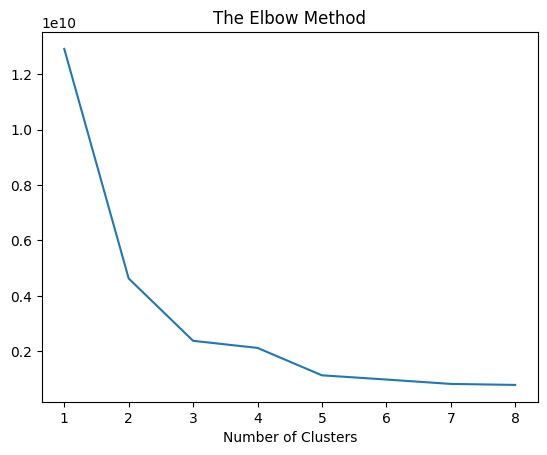

In [ ]:
plt.plot(range(1, 9), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.show() # 4 seems to be an Optimal Clusters amount

In [ ]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++')
y_kmeans = kmeans.fit_predict(x)

In [ ]:
# Adding each instance's Cluster no. on to the DataFrame

df_kmeans = pd.concat([df, pd.DataFrame(y_kmeans + 1, columns = ["Cluster no."])], axis = 1)
df_kmeans[["Amount Sold", "Cost Amount", "Cluster no."]].head(8)

,Amount Sold,Cost Amount,Cluster no.
0,64.44,29.76,1
1,120.00,81.36,1
2,496.62,122.31,2
3,39.34,20.05,1
4,53.46,18.47,1
5,166.46,45.86,1
6,182.63,72.48,1
7,182.63,72.48,1


#### Behold: The K-Means Clustering complete & Visuazlied for Interpreation!

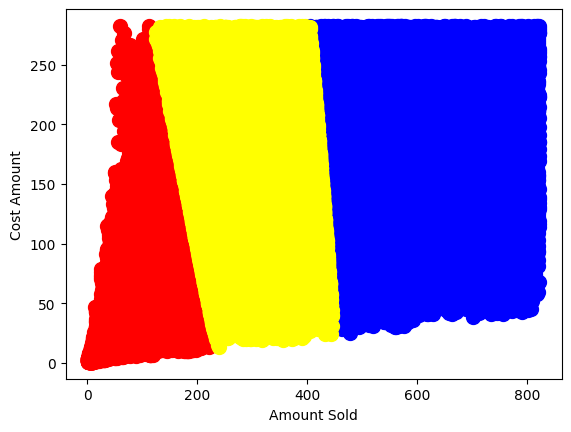

In [ ]:
# Visualization

# Creating a Scatterplot based on Product Price and Revenue-to-Cost Ratio
plt.scatter(x[y_kmeans == 0, 0], x[y_kmeans == 0, 1], s = 100, c = 'red') # Cluster no.1
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s = 100, c = 'blue') # Cluster no.2
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s = 100, c = 'yellow') # Cluster no.3
# plt.scatter(x[y_kmeans == 3, 0], x[y_kmeans == 3, 1], s = 100, c = 'black') # Cluster no.4

# "0, 0" = Cluster no. 1, Column no.1 (Price); "0, 1" = Cluster no.1, Column no. 2 (Revenue-to-Cost Ratio)

plt.xlabel("Amount Sold")
plt.ylabel("Cost Amount")
plt.show()

This Cluster plot - of UNSCALED data - seems to be driven primarily by the larger scale of "Amount Sold" and, thus, the Clusters are elongated horizontally.

Let's do the Cluster plot with Scaled data for these two, in order to get a more Accurate depiction.

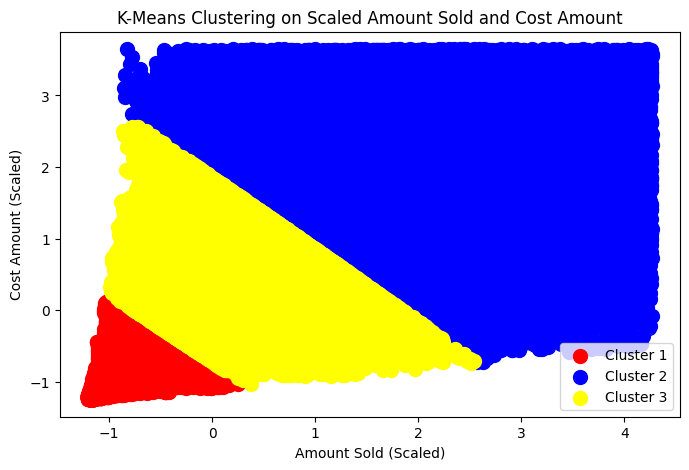

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df[["Amount Sold", "Cost Amount"]])

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
y_kmeans_scaled = kmeans.fit_predict(x_scaled)

df_kmeans_scaled = pd.concat([df, pd.DataFrame(y_kmeans_scaled + 1, columns=["Cluster no. Scaled"])], axis=1)

plt.figure(figsize=(8, 5))
plt.scatter(x_scaled[y_kmeans_scaled == 0, 0], x_scaled[y_kmeans_scaled == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(x_scaled[y_kmeans_scaled == 1, 0], x_scaled[y_kmeans_scaled == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(x_scaled[y_kmeans_scaled == 2, 0], x_scaled[y_kmeans_scaled == 2, 1], s=100, c='yellow', label='Cluster 3')
plt.xlabel("Amount Sold (Scaled)")
plt.ylabel("Cost Amount (Scaled)")
plt.title("K-Means Clustering on Scaled Amount Sold and Cost Amount")
plt.legend()
plt.show()

In [ ]:
# Interpreting the Clusters with their Original, Unscaled units
original_centroids = scaler.inverse_transform(kmeans.cluster_centers_)

print("Cluster Centers in Original Units:")
for i, center in enumerate(original_centroids):
    print(f"Cluster {i+1}: Amount Sold = {center[0]:.2f}, Cost Amount = {center[1]:.2f}")

print("")

# Actual Ranges of Values covered in each Cluster
for i in range(1, 4):
    cluster_data = df_kmeans_scaled[df_kmeans_scaled['Cluster no. Scaled'] == i][['Amount Sold', 'Cost Amount']]
    print(f"\nCluster {i}:")
    print(f"  Amount Sold (Min): {cluster_data['Amount Sold'].min():.2f}, (Max): {cluster_data['Amount Sold'].max():.2f}")
    print(f"  Cost Amount (Min): {cluster_data['Cost Amount'].min():.2f}, (Max): {cluster_data['Cost Amount'].max():.2f}")

Cluster Centers in Original Units:
Cluster 1: Amount Sold = 58.07, Cost Amount = 23.13
Cluster 2: Amount Sold = 443.04, Cost Amount = 173.09
Cluster 3: Amount Sold = 197.50, Cost Amount = 79.30


Cluster 1:
  Amount Sold (Min): 2.05, (Max): 222.18
  Cost Amount (Min): 0.80, (Max): 81.90

Cluster 2:
  Amount Sold (Min): 53.86, (Max): 821.55
  Cost Amount (Min): 30.54, (Max): 282.40

Cluster 3:
  Amount Sold (Min): 33.78, (Max): 563.82
  Cost Amount (Min): 12.96, (Max): 220.06


**Verdict:**

*   **Cluster 1:** Can be considered the 'Low Volume/Low Cost' or 'Entry-level Products' with 'Amount Sold' typically below $222 and 'Cost Amount' below $82. Focus: Niche markets, cost efficiency.

*   **Cluster 2:** Is definitely the "High-Volume and High-Revenue Generator Products" (Flagship/Key Items) representing key revenue drivers with a broad range up to $822 in sales and $282 in cost.
Focus: Market dominance, supply chain optimization.

*   **Cluster 3:** Moderate average sales ($198) and cost ($79), with "Amount Sold" ranging up to $564 and "Cost Amount" up to $220; can be Classified as "Mid-Range Performers with Potential for Growth."
Focus: Optimization, targeted marketing.

Further analysis could involve exploring different clustering algorithms or incorporating other relevant features (e.g., profit margin, product category) to gain a more comprehensive understanding of Product Segmentation.

Investigating the characteristics of products that fall near the boundaries between clusters could also provide valuable information.